In [ ]:
# BLOCK 1: Imports and Setup
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    mean_squared_error, mean_absolute_error, r2_score,
    confusion_matrix, classification_report
)
from sklearn.pipeline import Pipeline
import joblib

# Create a timestamp for the results directory
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
results_dir = f"results_{timestamp}"
os.makedirs(results_dir, exist_ok=True)

print("Setup complete and results directory created.")

# BLOCK 2: Data Generation Functions
def generate_simulation_data(num_simulations=1000, random_state=42):
    """
    Generate synthetic EEG simulation data.
    
    Parameters:
        num_simulations (int): Number of simulations to generate
        random_state (int): Random seed for reproducibility
    
    Returns:
        pd.DataFrame: DataFrame containing simulation parameters
    """
    np.random.seed(random_state)
    
    # Simulation parameters
    data = {
        'simulation_id': range(1, num_simulations + 1),
        'duration': np.random.uniform(10, 60, num_simulations),  # minutes
        'sampling_rate': np.random.choice([128, 256, 512, 1024], num_simulations),  # Hz
        'num_channels': np.random.randint(4, 32, num_simulations),
        'baseline_amplitude': np.random.uniform(5, 50, num_simulations),  # microvolts
        'noise_level': np.random.uniform(0.1, 2.0, num_simulations),
        'has_seizure': np.random.choice([0, 1], num_simulations, p=[0.7, 0.3]),
    }
    
    df = pd.DataFrame(data)
    
    # For simulations with seizures, add seizure parameters
    seizure_mask = df['has_seizure'] == 1
    num_seizures = seizure_mask.sum()
    
    # Initialize seizure columns with NaN
    df['seizure_count'] = np.nan
    df['time_to_first_seizure'] = np.nan
    df['seizure_duration'] = np.nan
    df['seizure_amplitude'] = np.nan
    df['seizure_frequency'] = np.nan
    
    # Fill seizure data only for rows with seizures
    df.loc[seizure_mask, 'seizure_count'] = np.random.randint(1, 5, num_seizures)
    
    # Time to first seizure (in seconds)
    max_times = df.loc[seizure_mask, 'duration'] * 60 * 0.8  # 80% of total duration max
    df.loc[seizure_mask, 'time_to_first_seizure'] = np.random.uniform(
        60, max_times, num_seizures
    )
    
    df.loc[seizure_mask, 'seizure_duration'] = np.random.uniform(
        5, 120, num_seizures
    )  # seconds
    
    df.loc[seizure_mask, 'seizure_amplitude'] = df.loc[seizure_mask, 'baseline_amplitude'] * np.random.uniform(
        2, 10, num_seizures
    )
    
    df.loc[seizure_mask, 'seizure_frequency'] = np.random.uniform(
        3, 20, num_seizures
    )  # Hz
    
    return df

def generate_eeg_features(simulation_data, random_state=42):
    """
    Generate EEG features based on simulation parameters.
    
    Parameters:
        simulation_data (pd.DataFrame): DataFrame with simulation parameters
        random_state (int): Random seed for reproducibility
    
    Returns:
        pd.DataFrame: DataFrame containing EEG features
    """
    np.random.seed(random_state)
    
    num_simulations = len(simulation_data)
    
    # Statistical features
    features = pd.DataFrame()
    features['simulation_id'] = simulation_data['simulation_id']
    
    # Basic statistical features
    features['mean_amplitude'] = np.where(
        simulation_data['has_seizure'] == 1,
        simulation_data['baseline_amplitude'] * np.random.uniform(1.2, 1.8, num_simulations),
        simulation_data['baseline_amplitude'] * np.random.uniform(0.8, 1.2, num_simulations)
    )
    
    features['std_amplitude'] = np.where(
        simulation_data['has_seizure'] == 1,
        simulation_data['baseline_amplitude'] * np.random.uniform(0.4, 1.2, num_simulations),
        simulation_data['baseline_amplitude'] * np.random.uniform(0.1, 0.4, num_simulations)
    )
    
    # Frequency domain features
    features['delta_power'] = np.where(
        simulation_data['has_seizure'] == 1,
        np.random.uniform(0.5, 2.0, num_simulations),
        np.random.uniform(0.1, 0.8, num_simulations)
    )
    
    features['theta_power'] = np.where(
        simulation_data['has_seizure'] == 1,
        np.random.uniform(0.8, 2.5, num_simulations),
        np.random.uniform(0.2, 1.0, num_simulations)
    )
    
    features['alpha_power'] = np.where(
        simulation_data['has_seizure'] == 1,
        np.random.uniform(0.2, 0.8, num_simulations),
        np.random.uniform(0.8, 2.0, num_simulations)
    )
    
    features['beta_power'] = np.where(
        simulation_data['has_seizure'] == 1,
        np.random.uniform(1.5, 3.0, num_simulations),
        np.random.uniform(0.5, 1.5, num_simulations)
    )
    
    features['gamma_power'] = np.where(
        simulation_data['has_seizure'] == 1,
        np.random.uniform(2.0, 5.0, num_simulations),
        np.random.uniform(0.3, 1.0, num_simulations)
    )
    
    # Complexity measures
    features['entropy'] = np.where(
        simulation_data['has_seizure'] == 1,
        np.random.uniform(0.1, 0.6, num_simulations),
        np.random.uniform(0.5, 0.9, num_simulations)
    )
    
    features['line_length'] = np.where(
        simulation_data['has_seizure'] == 1,
        simulation_data['baseline_amplitude'] * np.random.uniform(1.5, 3.0, num_simulations),
        simulation_data['baseline_amplitude'] * np.random.uniform(0.5, 1.5, num_simulations)
    )
    
    # Connectivity features (mimicking cross-channel correlations)
    features['mean_correlation'] = np.where(
        simulation_data['has_seizure'] == 1,
        np.random.uniform(0.6, 0.95, num_simulations),
        np.random.uniform(0.3, 0.7, num_simulations)
    )
    
    features['correlation_std'] = np.where(
        simulation_data['has_seizure'] == 1,
        np.random.uniform(0.05, 0.2, num_simulations),
        np.random.uniform(0.1, 0.3, num_simulations)
    )
    
    # Make features dependent on seizure parameters for simulations with seizures
    seizure_mask = simulation_data['has_seizure'] == 1
    
    if seizure_mask.sum() > 0:
        # Adjust features based on time to seizure
        time_to_seizure = simulation_data.loc[seizure_mask, 'time_to_first_seizure'].values
        max_time = np.max(time_to_seizure)
        
        # Normalized time (0-1)
        norm_time = time_to_seizure / max_time if max_time > 0 else np.zeros_like(time_to_seizure)
        
        # The closer to seizure, the more abnormal the features
        proximity_factor = 1 - norm_time
        
        # Adjust features based on proximity to seizure
        for feature in ['delta_power', 'theta_power', 'beta_power', 'gamma_power', 'line_length']:
            base_values = features.loc[seizure_mask, feature].values
            features.loc[seizure_mask, feature] = base_values * (1 + proximity_factor * 0.5)
        
        for feature in ['alpha_power', 'entropy']:
            base_values = features.loc[seizure_mask, feature].values
            features.loc[seizure_mask, feature] = base_values * (1 - proximity_factor * 0.3)
        
        # Add more complex features based on seizure parameters
        seizure_amplitude = simulation_data.loc[seizure_mask, 'seizure_amplitude'].values
        seizure_frequency = simulation_data.loc[seizure_mask, 'seizure_frequency'].values
        
        features.loc[seizure_mask, 'amplitude_ratio'] = (
            seizure_amplitude / simulation_data.loc[seizure_mask, 'baseline_amplitude'].values
        )
        
        features.loc[seizure_mask, 'frequency_change'] = (
            seizure_frequency / np.random.uniform(8, 12, len(seizure_frequency))
        )
    
    else:
        # Handle the case where there are no seizures
        features['amplitude_ratio'] = np.random.uniform(0.8, 1.2, num_simulations)
        features['frequency_change'] = np.random.uniform(0.9, 1.1, num_simulations)
    
    # Add some noise to all features
    for col in features.columns:
        if col != 'simulation_id':
            features[col] = features[col] * np.random.normal(1, 0.05, num_simulations)
    
    return features

print("Data generation functions defined.")

# BLOCK 3: Generate Data
def generate_dataset(num_simulations=10000, random_state=42):
    """
    Generate a full dataset with simulation parameters, EEG features, and targets.
    
    Parameters:
        num_simulations (int): Number of simulations to generate
        random_state (int): Random seed for reproducibility
    
    Returns:
        tuple:
            - pd.DataFrame: Simulation parameters
            - pd.DataFrame: EEG features
            - pd.DataFrame: Target variables
    """
    # Generate simulation data
    print(f"Generating {num_simulations} simulations...")
    simulation_data = generate_simulation_data(num_simulations, random_state)
    
    # Generate EEG features based on simulation parameters
    print("Generating EEG features...")
    features = generate_eeg_features(simulation_data, random_state)
    
    # Create target variables
    print("Creating target variables...")
    targets = pd.DataFrame()
    targets['simulation_id'] = simulation_data['simulation_id']
    targets['has_seizure'] = simulation_data['has_seizure']
    
    # For simulations with seizures, add time to seizure in seconds
    targets['time_to_seizure'] = np.nan
    seizure_mask = simulation_data['has_seizure'] == 1
    targets.loc[seizure_mask, 'time_to_seizure'] = simulation_data.loc[
        seizure_mask, 'time_to_first_seizure'
    ]
    
    return simulation_data, features, targets

# Generate data
simulation_data, features, targets = generate_dataset(num_simulations=1000)

# Check that data was created correctly
print(f"Simulation data shape: {simulation_data.shape}")
print(f"Features shape: {features.shape}")
print(f"Targets shape: {targets.shape}")

# Display a few rows of each
print("\nSimulation data sample:")
display(simulation_data.head())

print("\nFeatures sample:")
display(features.head())

print("\nTargets sample:")
display(targets.head())

# BLOCK 4: Data Preprocessing
def preprocess_data(features, targets):
    """
    Preprocess the features and targets.
    
    Parameters:
        features (pd.DataFrame): Feature matrix
        targets (pd.DataFrame): Target variables
    
    Returns:
        tuple:
            - pd.DataFrame: Processed features
            - pd.DataFrame: Processed targets
    """
    print("Preprocessing data...")
    
    # Make a copy to avoid modifying the original
    features_processed = features.copy()
    targets_processed = targets.copy()
    
    # Remove ID column for modeling but keep for reference
    features_id = features_processed['simulation_id']
    features_processed = features_processed.drop(columns=['simulation_id'])
    
    # For time_to_seizure prediction, we only use rows where has_seizure=1
    # but we'll prepare that subset in the training function
    
    # Check for missing values
    print(f"Missing values in features: {features_processed.isna().sum().sum()}")
    print(f"Missing values in targets: {targets_processed.isna().sum().sum()}")
    
    # Fill missing values in features if any
    if features_processed.isna().sum().sum() > 0:
        features_processed = features_processed.fillna(features_processed.mean())
    
    # Check for outliers (simplified approach using IQR)
    Q1 = features_processed.quantile(0.25)
    Q3 = features_processed.quantile(0.75)
    IQR = Q3 - Q1
    
    outlier_mask = ((features_processed < (Q1 - 1.5 * IQR)) | 
                    (features_processed > (Q3 + 1.5 * IQR))).any(axis=1)
    
    print(f"Number of potential outliers detected: {outlier_mask.sum()}")
    
    # For this example, we'll keep outliers but in a real application,
    # you might want to handle them differently
    
    # Add back the ID for reference
    features_processed.insert(0, 'simulation_id', features_id)
    
    return features_processed, targets_processed

# Preprocess the data
features_processed, targets_processed = preprocess_data(features, targets)

# Display shapes after preprocessing
print(f"\nProcessed features shape: {features_processed.shape}")
print(f"Processed targets shape: {targets_processed.shape}")

# BLOCK 5: Data Splitting for Model Training
def prepare_for_training(features, targets):
    """
    Prepare processed data for model training by removing ID columns.
    
    Parameters:
        features (pd.DataFrame): Processed features
        targets (pd.DataFrame): Processed targets
    
    Returns:
        tuple:
            - pd.DataFrame: Features for modeling
            - pd.DataFrame: Targets for modeling
    """
    # Remove ID columns for modeling
    features_for_modeling = features.drop(columns=['simulation_id'])
    targets_for_modeling = targets.drop(columns=['simulation_id'])
    
    print(f"Features for modeling shape: {features_for_modeling.shape}")
    print(f"Targets for modeling shape: {targets_for_modeling.shape}")
    
    return features_for_modeling, targets_for_modeling

# Prepare data for training
features_for_modeling, targets_for_modeling = prepare_for_training(features_processed, targets_processed)

# BLOCK 6: Model Training Function
def train_seizure_prediction_models(features, targets, test_size=0.2, random_state=42):
    """
    Train models to predict seizure occurrence and onset time.
    
    Parameters:
        features (pd.DataFrame): Feature matrix
        targets (pd.DataFrame): Target variables (has_seizure, time_to_seizure)
        test_size (float): Proportion of data to use for testing
        random_state (int): Random seed for reproducibility
    
    Returns:
        tuple:
            - dict: Trained models
            - dict: Dictionary containing model performance metrics
    """
    # Debug: Check if features or targets are empty
    print(f"Features shape: {features.shape}")
    print(f"Targets shape: {targets.shape}")
    
    if features.shape[0] == 0 or targets.shape[0] == 0:
        raise ValueError("Features or targets DataFrame is empty. Check your data processing steps.")
    
    # Split data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(
        features, targets, test_size=test_size, random_state=random_state
    )
    
    # Create classification model for seizure occurrence
    seizure_classifier = Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', RandomForestClassifier(n_estimators=100, random_state=random_state))
    ])
    
    # Train seizure occurrence classifier
    print("Training seizure occurrence classifier...")
    seizure_classifier.fit(X_train, y_train['has_seizure'])
    
    # Predict on test set
    y_pred_seizure = seizure_classifier.predict(X_test)
    
    # Calculate metrics for seizure occurrence
    accuracy = accuracy_score(y_test['has_seizure'], y_pred_seizure)
    precision = precision_score(y_test['has_seizure'], y_pred_seizure)
    recall = recall_score(y_test['has_seizure'], y_pred_seizure)
    f1 = f1_score(y_test['has_seizure'], y_pred_seizure)
    
    print(f"Seizure Classifier Metrics:")
    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall: {recall:.4f}")
    print(f"  F1 Score: {f1:.4f}")
    
    # Create regression model for seizure time prediction
    # Only use data points where seizures occur
    seizure_mask_train = y_train['has_seizure'] == 1
    seizure_mask_test = y_test['has_seizure'] == 1
    
    # Check if we have seizure data to train the regression model
    if seizure_mask_train.sum() > 0 and seizure_mask_test.sum() > 0:
        X_train_seizure = X_train[seizure_mask_train]
        y_train_seizure = y_train.loc[seizure_mask_train, 'time_to_seizure']
        
        X_test_seizure = X_test[seizure_mask_test]
        y_test_seizure = y_test.loc[seizure_mask_test, 'time_to_seizure']
        
        seizure_regressor = Pipeline([
            ('scaler', StandardScaler()),
            ('regressor', RandomForestRegressor(n_estimators=100, random_state=random_state))
        ])
        
        # Train seizure time predictor
        print("Training seizure time prediction model...")
        seizure_regressor.fit(X_train_seizure, y_train_seizure)
        
        # Predict on test set
        y_pred_time = seizure_regressor.predict(X_test_seizure)
        
        # Calculate metrics for time prediction
        mse = mean_squared_error(y_test_seizure, y_pred_time)
        rmse = np.sqrt(mse)
        mae = mean_absolute_error(y_test_seizure, y_pred_time)
        r2 = r2_score(y_test_seizure, y_pred_time)
        
        print(f"Seizure Time Predictor Metrics:")
        print(f"  Mean Squared Error: {mse:.4f}")
        print(f"  Root Mean Squared Error: {rmse:.4f}")
        print(f"  Mean Absolute Error: {mae:.4f}")
        print(f"  R² Score: {r2:.4f}")
    else:
        print("Not enough seizure data to train the regression model")
        seizure_regressor = None
        rmse = mae = r2 = None
    
    # Store models and metrics
    models = {
        'seizure_classifier': seizure_classifier,
        'seizure_regressor': seizure_regressor
    }
    
    metrics = {
        'classification': {
            'accuracy': accuracy,
            'precision': precision,
            'recall': recall,
            'f1': f1
        },
        'regression': {
            'rmse': rmse,
            'mae': mae,
            'r2': r2
        }
    }
    
    return models, metrics

# BLOCK 7: Train Models
# Train models
print("Training models...")
models, metrics = train_seizure_prediction_models(features_for_modeling, targets_for_modeling)

# BLOCK 8: Visualize Results
def visualize_results(features, targets, models, results_dir):
    """
    Create visualizations for model results.
    
    Parameters:
        features (pd.DataFrame): Feature matrix
        targets (pd.DataFrame): Target variables
        models (dict): Dictionary of trained models
        results_dir (str): Directory to save results
    """
    # Split data again for visualization
    X_train, X_test, y_train, y_test = train_test_split(
        features, targets, test_size=0.2, random_state=42
    )
    
    # Seizure classifier predictions
    y_pred_proba = models['seizure_classifier'].predict_proba(X_test)[:, 1]
    y_pred = models['seizure_classifier'].predict(X_test)
    
    # Create confusion matrix
    cm = confusion_matrix(y_test['has_seizure'], y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['No Seizure', 'Seizure'],
                yticklabels=['No Seizure', 'Seizure'])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix - Seizure Prediction')
    plt.tight_layout()
    plt.savefig(os.path.join(results_dir, 'confusion_matrix.png'))
    plt.close()
    
    # ROC curve for seizure classification
    from sklearn.metrics import roc_curve, roc_auc_score
    fpr, tpr, _ = roc_curve(y_test['has_seizure'], y_pred_proba)
    auc = roc_auc_score(y_test['has_seizure'], y_pred_proba)
    
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {auc:.2f})')
    plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve - Seizure Prediction')
    plt.legend(loc='lower right')
    plt.savefig(os.path.join(results_dir, 'roc_curve.png'))
    plt.close()
    
    # Histogram of predicted probabilities by actual class
    plt.figure(figsize=(10, 6))
    sns.histplot(y_pred_proba[y_test['has_seizure'] == 0], 
                 color='green', alpha=0.5, bins=20, label='No Seizure')
    sns.histplot(y_pred_proba[y_test['has_seizure'] == 1], 
                 color='red', alpha=0.5, bins=20, label='Seizure')
    plt.xlabel('Predicted Probability of Seizure')
    plt.ylabel('Count')
    plt.title('Distribution of Predicted Probabilities by Actual Class')
    plt.legend()
    plt.savefig(os.path.join(results_dir, 'probability_distribution.png'))
    plt.close()
    
    # Feature importance for seizure classifier
    feature_names = features.columns
    importances = models['seizure_classifier'].named_steps['classifier'].feature_importances_
    indices = np.argsort(importances)[::-1]
    
    plt.figure(figsize=(12, 8))
    plt.bar(range(len(importances)), importances[indices])
    plt.xticks(range(len(importances)), [feature_names[i] for i in indices], rotation=90)
    plt.xlabel('Features')
    plt.ylabel('Importance')
    plt.title('Feature Importance for Seizure Prediction')
    plt.tight_layout()
    plt.savefig(os.path.join(results_dir, 'feature_importance.png'))
    plt.close()
    
    # For seizure time predictor, if available
    if models['seizure_regressor'] is not None:
        # Only use data with seizures
        seizure_mask = y_test['has_seizure'] == 1
        X_test_seizure = X_test[seizure_mask]
        y_test_seizure = y_test.loc[seizure_mask, 'time_to_seizure']
        
        if len(X_test_seizure) > 0:
            y_pred_time = models['seizure_regressor'].predict(X_test_seizure)
            
            # Scatter plot of actual vs predicted seizure time
            plt.figure(figsize=(8, 8))
            plt.scatter(y_test_seizure, y_pred_time, alpha=0.6)
            plt.plot([0, max(y_test_seizure)], [0, max(y_test_seizure)], 'r--')
            plt.xlabel('Actual Time to Seizure (seconds)')
            plt.ylabel('Predicted Time to Seizure (seconds)')
            plt.title('Actual vs Predicted Time to Seizure')
            plt.savefig(os.path.join(results_dir, 'time_prediction.png'))
            plt.close()
            
            # Feature importance for seizure time predictor
            importances = models['seizure_regressor'].named_steps['regressor'].feature_importances_
            indices = np.argsort(importances)[::-1]
            
            plt.figure(figsize=(12, 8))
            plt.bar(range(len(importances)), importances[indices])
            plt.xticks(range(len(importances)), [feature_names[i] for i in indices], rotation=90)
            plt.xlabel('Features')
            plt.ylabel('Importance')
            plt.title('Feature Importance for Seizure Time Prediction')
            plt.tight_layout()
            plt.savefig(os.path.join(results_dir, 'time_feature_importance.png'))
            plt.close()

# BLOCK 9: Save Models and Results
def save_results(models, metrics, simulation_data, features, targets, results_dir):
    """
    Save models, metrics, and data for future use.
    
    Parameters:
        models (dict): Dictionary of trained models
        metrics (dict): Dictionary of model metrics
        simulation_data (pd.DataFrame): Simulation parameters
        features (pd.DataFrame): Feature matrix
        targets (pd.DataFrame): Target variables
        results_dir (str): Directory to save results
    """
    # Save models
    joblib.dump(models, os.path.join(results_dir, 'models.joblib'))
    
    # Save metrics as JSON
    import json
    with open(os.path.join(results_dir, 'metrics.json'), 'w') as f:
        json.dump(metrics, f, indent=4)
    
    # Save data
    simulation_data.to_csv(os.path.join(results_dir, 'simulation_data.csv'), index=False)
    features.to_csv(os.path.join(results_dir, 'features.csv'), index=False)
    targets.to_csv(os.path.join(results_dir, 'targets.csv'), index=False)
    
    print(f"All results saved to {results_dir}")

# BLOCK 10: Main Function
def main():
    """
    Run the full seizure prediction pipeline.
    """
    # Generate dataset
    sim_data, feat, targ = generate_dataset(num_simulations=1000)
    
    # Preprocess data
    feat_processed, targ_processed = preprocess_data(feat, targ)
    
    # Prepare for training (remove IDs)
    feat_model, targ_model = prepare_for_training(feat_processed, targ_processed)
    
    # Debug: Check features and targets before model training
    print(f"Before model training - Features shape: {feat_model.shape}")
    print(f"Before model training - Targets shape: {targ_model.shape}")
    print(f"Features columns: {feat_model.columns.tolist()}")
    print(f"Targets columns: {targ_model.columns.tolist()}")
    
    # Train models
    models, metrics = train_seizure_prediction_models(feat_model, targ_model)
    
    # Visualize results
    visualize_results(feat_model, targ_model, models, results_dir)
    
    # Save results
    save_results(models, metrics, sim_data, feat_processed, targ_processed, results_dir)
    
    return models, results_dir

# BLOCK 11: Example Usage
# Run the main pipeline
if __name__ == "__main__":
    models, results_dir = main()
    
    # Example: using the model for prediction with new data
    print("\nExample: Predicting with new simulation parameters")
    
    # Generate a single new simulation
    new_sim = generate_simulation_data(num_simulations=1)
    new_features = generate_eeg_features(new_sim)
    
    # Preprocess and prepare for prediction
    new_features_id = new_features['simulation_id'].copy()
    new_features = new_features.drop(columns=['simulation_id'])
    
    # Make predictions
    seizure_prob = models['seizure_classifier'].predict_proba(new_features)[:, 1][0]
    seizure_pred = models['seizure_classifier'].predict(new_features)[0]
    
    print(f"Predicted seizure probability: {seizure_prob:.4f}")
    print(f"Seizure predicted: {'Yes' if seizure_pred == 1 else 'No'}")
    
    # If seizure predicted and we have a regression model, predict time
    if seizure_pred == 1 and models['seizure_regressor'] is not None:
        time_pred = models['seizure_regressor'].predict(new_features)[0]
        print(f"Predicted time to seizure: {time_pred:.2f} seconds")
    
    print("\nPipeline execution complete!")

**Library Imports, Data Generation, Data Preprocessing, Data Splitting**

/opt/anaconda3/lib/python3.11/site-packages/gym/spaces/box.py:127: UserWarning: WARN: Box bound precision lowered by casting to float32
  logger.warn(f"Box bound precision lowered by casting to {self.dtype}")


Step 1, Action: [ 1.  40.   1.5], SNR: -9.29 dB
Step 2, Action: [ 3.  42.   1.5], SNR: -9.23 dB
Step 3, Action: [ 5.  44.   1.5], SNR: -8.98 dB
Step 4, Action: [ 7.  46.   1.5], SNR: -8.75 dB
Step 5, Action: [ 9.  48.   1.5], SNR: -8.53 dB
Step 6, Action: [11.  50.   1.5], SNR: -8.30 dB
Step 7, Action: [13.  52.   1.5], SNR: -8.10 dB
Step 8, Action: [15.  54.   1.5], SNR: -7.91 dB
Step 9, Action: [17.  56.   1.5], SNR: -7.69 dB
Step 10, Action: [19.  58.   1.5], SNR: -7.44 dB


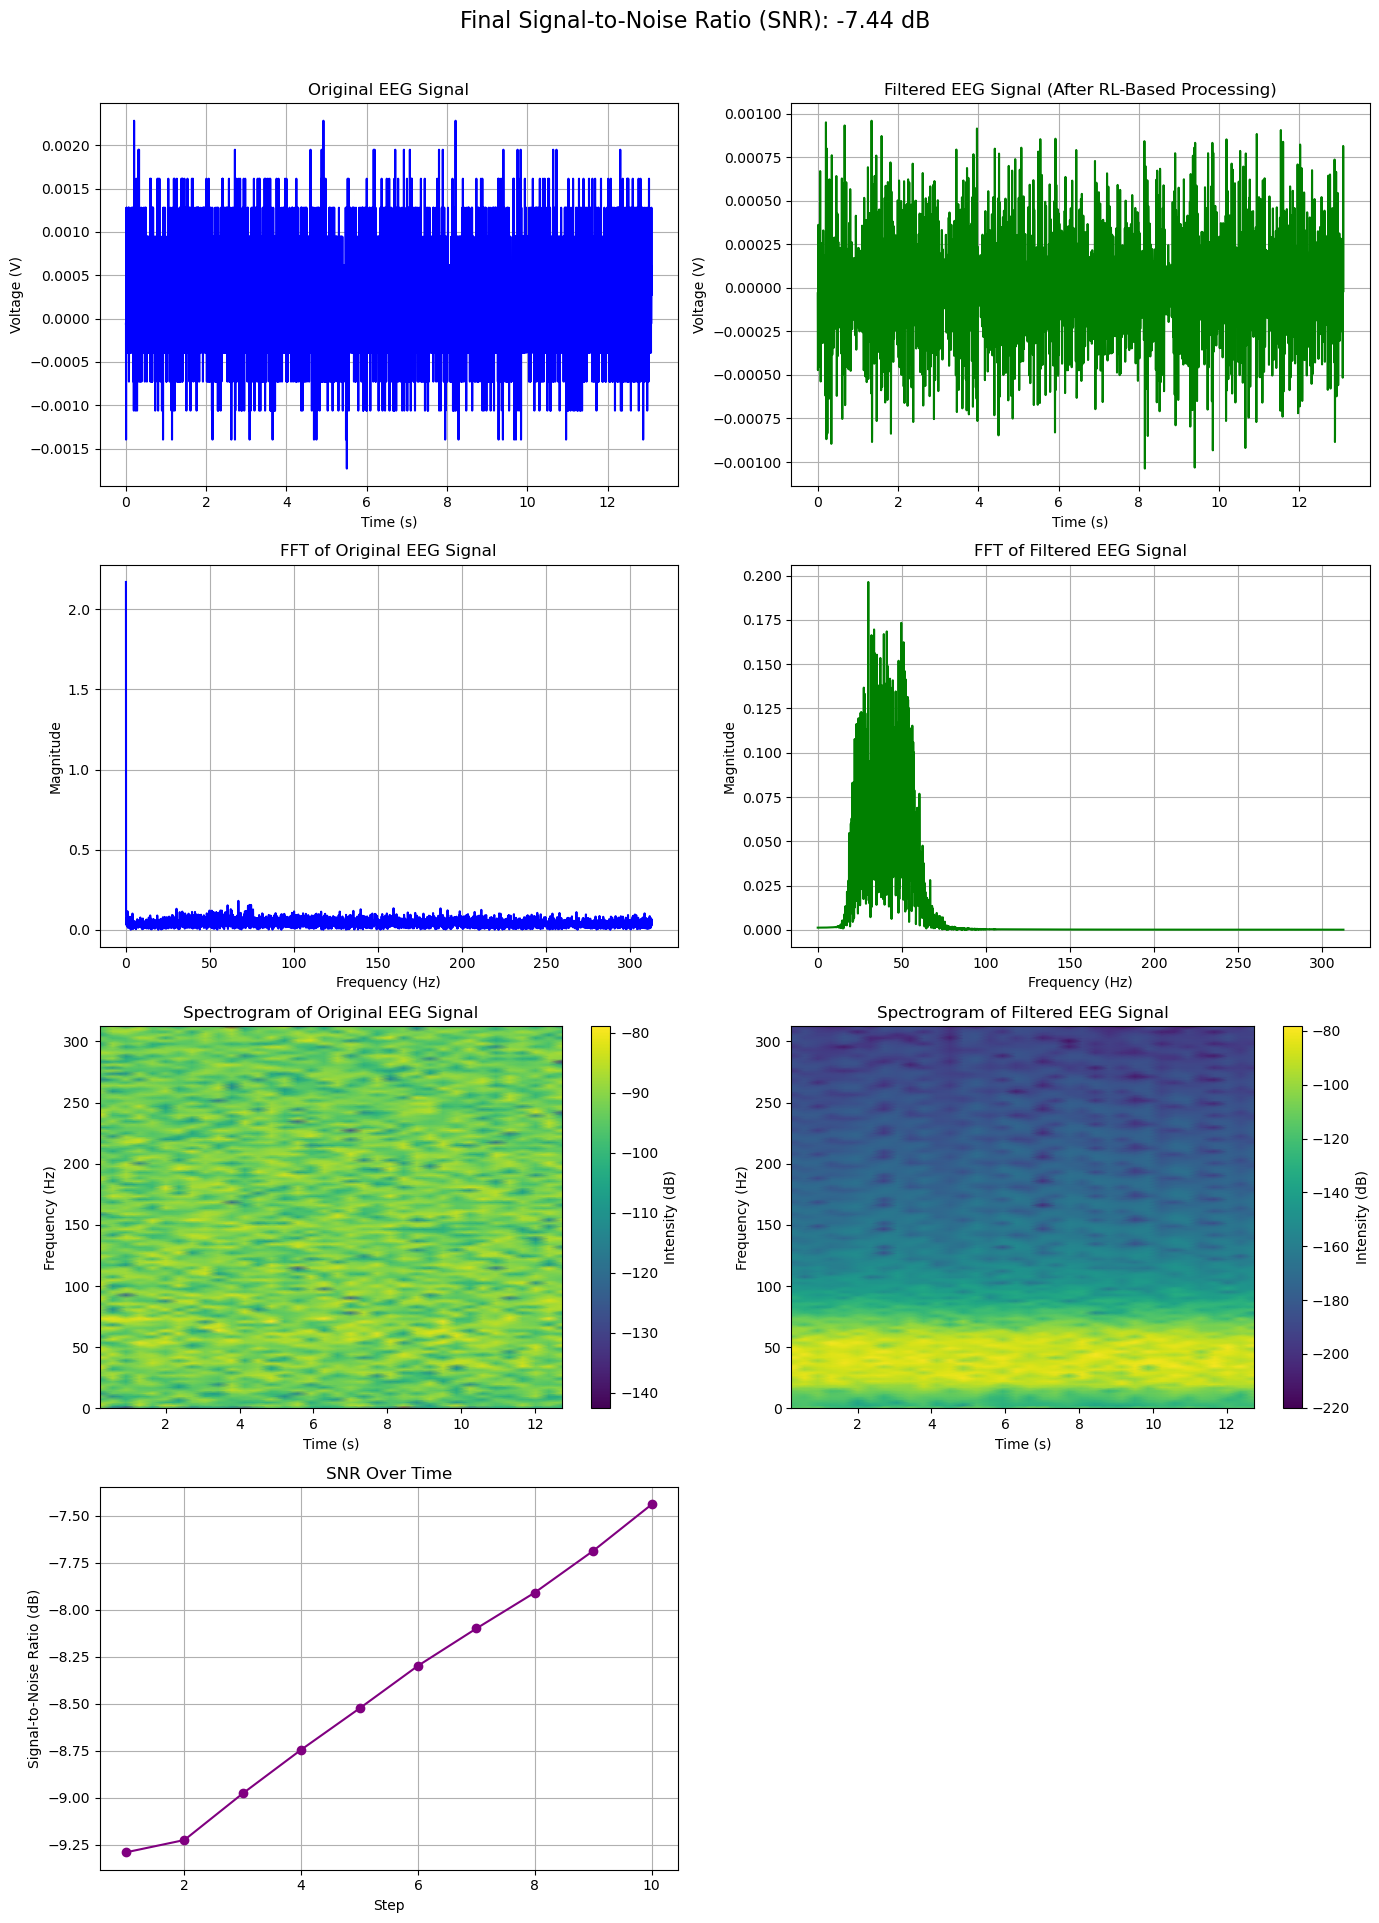

Data generation functions defined.


NameError: name 'features' is not defined

In [3]:
import os
import time
import json
import joblib
import numpy as np
import pandas as pd
from scipy.signal import butter, filtfilt
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt

######################################################################################################################################################################
# RL Environment for EEG Filtering
from scipy import signal
import gym
from gym import spaces
from scipy.stats import entropy, wasserstein_distance
from scipy.signal import welch

# Load EEG signal
fs = 625.34  
data = pd.read_csv('AD2Oscillascope60secrec.csv', comment='#')
channel1 = data['Channel 1 (V)'].values
time_axis = np.arange(len(channel1)) / fs  # Convert samples to time

# Define the RL environment
class SignalFilterEnv(gym.Env):
    def __init__(self, raw_signal, sample_rate):
        super(SignalFilterEnv, self).__init__()
        self.raw_signal = raw_signal
        self.fs = sample_rate
        self.signal_length = len(raw_signal)
        
        # Define action and observation space
        self.action_space = spaces.Box(
            low=np.array([0.1, 0.2, 0.1]),
            high=np.array([30.0, 100.0, 10.0]),
            dtype=np.float32
        )
        self.observation_space = spaces.Box(
            low=-np.inf,
            high=np.inf,
            shape=(self.signal_length,),
            dtype=np.float32
        )
        
        # Reference EEG signal properties (synthetic or real data)
        self.reference_psd = self.compute_psd(raw_signal)
    
    def compute_psd(self, signal):
        freqs, psd = welch(signal, self.fs, nperseg=1024)
        return psd
    
    def apply_filters(self, action):
        lowcut, highcut, gain = sorted(action[:2]) + [action[2]]
        nyq = 0.5 * self.fs
        lowcut, highcut = max(0.1, lowcut), max(lowcut + 1.0, highcut)
        
        b, a = signal.butter(4, [lowcut / nyq, highcut / nyq], btype='band')
        filtered_signal = signal.filtfilt(b, a, self.raw_signal)
        amplified_signal = np.clip(gain * filtered_signal, -np.max(self.raw_signal), np.max(self.raw_signal))
        return amplified_signal
    
    def calculate_reward(self, filtered_signal):
        psd_filtered = self.compute_psd(filtered_signal)
        spectral_distance = wasserstein_distance(self.reference_psd, psd_filtered)
        
        noise = self.raw_signal - filtered_signal
        noise_power = np.mean(noise**2)
        signal_power = np.mean(filtered_signal**2)
        snr = 10 * np.log10(signal_power / (noise_power + 1e-10))
        
        entropy_diff = abs(entropy(self.reference_psd) - entropy(psd_filtered))
        reward = snr - spectral_distance - entropy_diff  # Encourage SNR, discourage distortion
        return reward
    
    def step(self, action):
        filtered_signal = self.apply_filters(action)
        reward = self.calculate_reward(filtered_signal)
        return filtered_signal, reward, False, {}
    
    def reset(self):
        return self.raw_signal

# Initialize environment
env = SignalFilterEnv(channel1, fs)

# Run RL-based filtering over multiple steps
num_steps = 10
filtered_signals = []
snr_values = []

for step in range(num_steps):
    action = np.array([1.0 + step * 2, 40.0 + step * 2, 1.5])
    filtered_signal, reward, _, _ = env.step(action)
    filtered_signals.append(filtered_signal)
    snr_values.append(reward)
    print(f"Step {step + 1}, Action: {action}, SNR: {reward:.2f} dB")

# Compute FFT of original and filtered signals
def compute_fft(signal, fs):
    n = len(signal)
    freqs = np.fft.rfftfreq(n, d=1/fs)
    fft_values = np.abs(np.fft.rfft(signal))
    return freqs, fft_values

final_filtered_signal = filtered_signals[-1]
freqs_raw, fft_raw = compute_fft(channel1, fs)
freqs_filtered, fft_filtered = compute_fft(final_filtered_signal, fs)

# Function to plot spectrogram
def plot_spectrogram(eeg_data, fs, title, ax):
    f, t, Sxx = signal.spectrogram(eeg_data, fs)
    im = ax.pcolormesh(t, f, 10 * np.log10(Sxx), shading='gouraud')
    ax.set_title(title)
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Frequency (Hz)')
    fig.colorbar(im, ax=ax, label='Intensity (dB)')

# Plot results
fig, axes = plt.subplots(4, 2, figsize=(14, 20))

# Original EEG signal
axes[0, 0].plot(time_axis, channel1, color='blue')
axes[0, 0].set_xlabel('Time (s)')
axes[0, 0].set_ylabel('Voltage (V)')
axes[0, 0].set_title('Original EEG Signal')
axes[0, 0].grid()

# Filtered EEG signal (last step)
axes[0, 1].plot(time_axis, final_filtered_signal, color='green')
axes[0, 1].set_xlabel('Time (s)')
axes[0, 1].set_ylabel('Voltage (V)')
axes[0, 1].set_title('Filtered EEG Signal (After RL-Based Processing)')
axes[0, 1].grid()

# FFT of original signal
axes[1, 0].plot(freqs_raw, fft_raw, color='blue')
axes[1, 0].set_xlabel('Frequency (Hz)')
axes[1, 0].set_ylabel('Magnitude')
axes[1, 0].set_title('FFT of Original EEG Signal')
axes[1, 0].grid()

# FFT of filtered signal
axes[1, 1].plot(freqs_filtered, fft_filtered, color='green')
axes[1, 1].set_xlabel('Frequency (Hz)')
axes[1, 1].set_ylabel('Magnitude')
axes[1, 1].set_title('FFT of Filtered EEG Signal')
axes[1, 1].grid()

# Spectrogram of original signal
plot_spectrogram(channel1, fs, 'Spectrogram of Original EEG Signal', axes[2, 0])

# Spectrogram of filtered signal
plot_spectrogram(final_filtered_signal, fs, 'Spectrogram of Filtered EEG Signal', axes[2, 1])

# Plot SNR over time
time_steps = np.arange(1, num_steps + 1)
axes[3, 0].plot(time_steps, snr_values, marker='o', color='purple')
axes[3, 0].set_xlabel('Step')
axes[3, 0].set_ylabel('Signal-to-Noise Ratio (dB)')
axes[3, 0].set_title('SNR Over Time')
axes[3, 0].grid()

# Empty subplot for symmetry
axes[3, 1].axis('off')

# Add overall SNR value to the plot
final_snr = env.calculate_reward(final_filtered_signal)
fig.text(0.5, 0.95, f'Final Signal-to-Noise Ratio (SNR): {final_snr:.2f} dB', ha='center', fontsize=16)

plt.tight_layout(rect=[0, 0, 1, 0.93])  # Adjust layout for the SNR text
plt.show()


######################################################################################################################################################################
# SIMULATED DATA GENERATION
def generate_simulation_data(num_simulations=1000, random_state=42):
    """
    Generate synthetic EEG simulation data.
    
    Parameters:
        num_simulations (int): Number of simulations to generate
        random_state (int): Random seed for reproducibility
    
    Returns:
        pd.DataFrame: DataFrame containing simulation parameters
    """
    np.random.seed(random_state)
    
    # Simulation parameters
    data = {
        'simulation_id': range(1, num_simulations + 1),
        'duration': np.random.uniform(10, 60, num_simulations),  # minutes
        'sampling_rate': np.random.choice([128, 256, 512, 1024], num_simulations),  # Hz
        'num_channels': np.random.randint(4, 32, num_simulations),
        'baseline_amplitude': np.random.uniform(5, 50, num_simulations),  # microvolts
        'noise_level': np.random.uniform(0.1, 2.0, num_simulations),
        'has_seizure': np.random.choice([0, 1], num_simulations, p=[0.7, 0.3]),
    }
    
    df = pd.DataFrame(data)
    
    # For simulations with seizures, add seizure parameters
    seizure_mask = df['has_seizure'] == 1
    num_seizures = seizure_mask.sum()
    
    # Initialize seizure columns with NaN
    df['seizure_count'] = np.nan
    df['time_to_first_seizure'] = np.nan
    df['seizure_duration'] = np.nan
    df['seizure_amplitude'] = np.nan
    df['seizure_frequency'] = np.nan
    
    # Fill seizure data only for rows with seizures
    df.loc[seizure_mask, 'seizure_count'] = np.random.randint(1, 5, num_seizures)
    
    # Time to first seizure (in seconds)
    max_times = df.loc[seizure_mask, 'duration'] * 60 * 0.8  # 80% of total duration max
    df.loc[seizure_mask, 'time_to_first_seizure'] = np.random.uniform(
        60, max_times, num_seizures
    )
    
    df.loc[seizure_mask, 'seizure_duration'] = np.random.uniform(
        5, 120, num_seizures
    )  # seconds
    
    df.loc[seizure_mask, 'seizure_amplitude'] = df.loc[seizure_mask, 'baseline_amplitude'] * np.random.uniform(
        2, 10, num_seizures
    )
    
    df.loc[seizure_mask, 'seizure_frequency'] = np.random.uniform(
        3, 20, num_seizures
    )  # Hz
    
    return df

def generate_eeg_features(simulation_data, random_state=42):
    """
    Generate EEG features based on simulation parameters.
    
    Parameters:
        simulation_data (pd.DataFrame): DataFrame with simulation parameters
        random_state (int): Random seed for reproducibility
    
    Returns:
        pd.DataFrame: DataFrame containing EEG features
    """
    np.random.seed(random_state)
    
    num_simulations = len(simulation_data)
    
    # Statistical features
    features = pd.DataFrame()
    features['simulation_id'] = simulation_data['simulation_id']
    
    # Basic statistical features
    features['mean_amplitude'] = np.where(
        simulation_data['has_seizure'] == 1,
        simulation_data['baseline_amplitude'] * np.random.uniform(1.2, 1.8, num_simulations),
        simulation_data['baseline_amplitude'] * np.random.uniform(0.8, 1.2, num_simulations)
    )
    
    features['std_amplitude'] = np.where(
        simulation_data['has_seizure'] == 1,
        simulation_data['baseline_amplitude'] * np.random.uniform(0.4, 1.2, num_simulations),
        simulation_data['baseline_amplitude'] * np.random.uniform(0.1, 0.4, num_simulations)
    )
    
    # Frequency domain features
    features['delta_power'] = np.where(
        simulation_data['has_seizure'] == 1,
        np.random.uniform(0.5, 2.0, num_simulations),
        np.random.uniform(0.1, 0.8, num_simulations)
    )
    
    features['theta_power'] = np.where(
        simulation_data['has_seizure'] == 1,
        np.random.uniform(0.8, 2.5, num_simulations),
        np.random.uniform(0.2, 1.0, num_simulations)
    )
    
    features['alpha_power'] = np.where(
        simulation_data['has_seizure'] == 1,
        np.random.uniform(0.2, 0.8, num_simulations),
        np.random.uniform(0.8, 2.0, num_simulations)
    )
    
    features['beta_power'] = np.where(
        simulation_data['has_seizure'] == 1,
        np.random.uniform(1.5, 3.0, num_simulations),
        np.random.uniform(0.5, 1.5, num_simulations)
    )
    
    features['gamma_power'] = np.where(
        simulation_data['has_seizure'] == 1,
        np.random.uniform(2.0, 5.0, num_simulations),
        np.random.uniform(0.3, 1.0, num_simulations)
    )
    
    # Complexity measures
    features['entropy'] = np.where(
        simulation_data['has_seizure'] == 1,
        np.random.uniform(0.1, 0.6, num_simulations),
        np.random.uniform(0.5, 0.9, num_simulations)
    )
    
    features['line_length'] = np.where(
        simulation_data['has_seizure'] == 1,
        simulation_data['baseline_amplitude'] * np.random.uniform(1.5, 3.0, num_simulations),
        simulation_data['baseline_amplitude'] * np.random.uniform(0.5, 1.5, num_simulations)
    )
    
    # Connectivity features (mimicking cross-channel correlations)
    features['mean_correlation'] = np.where(
        simulation_data['has_seizure'] == 1,
        np.random.uniform(0.6, 0.95, num_simulations),
        np.random.uniform(0.3, 0.7, num_simulations)
    )
    
    features['correlation_std'] = np.where(
        simulation_data['has_seizure'] == 1,
        np.random.uniform(0.05, 0.2, num_simulations),
        np.random.uniform(0.1, 0.3, num_simulations)
    )
    
    # Make features dependent on seizure parameters for simulations with seizures
    seizure_mask = simulation_data['has_seizure'] == 1
    
    if seizure_mask.sum() > 0:
        # Adjust features based on time to seizure
        time_to_seizure = simulation_data.loc[seizure_mask, 'time_to_first_seizure'].values
        max_time = np.max(time_to_seizure)
        
        # Normalized time (0-1)
        norm_time = time_to_seizure / max_time if max_time > 0 else np.zeros_like(time_to_seizure)
        
        # The closer to seizure, the more abnormal the features
        proximity_factor = 1 - norm_time
        
        # Adjust features based on proximity to seizure
        for feature in ['delta_power', 'theta_power', 'beta_power', 'gamma_power', 'line_length']:
            base_values = features.loc[seizure_mask, feature].values
            features.loc[seizure_mask, feature] = base_values * (1 + proximity_factor * 0.5)
        
        for feature in ['alpha_power', 'entropy']:
            base_values = features.loc[seizure_mask, feature].values
            features.loc[seizure_mask, feature] = base_values * (1 - proximity_factor * 0.3)
        
        # Add more complex features based on seizure parameters
        seizure_amplitude = simulation_data.loc[seizure_mask, 'seizure_amplitude'].values
        seizure_frequency = simulation_data.loc[seizure_mask, 'seizure_frequency'].values
        
        features.loc[seizure_mask, 'amplitude_ratio'] = (
            seizure_amplitude / simulation_data.loc[seizure_mask, 'baseline_amplitude'].values
        )
        
        features.loc[seizure_mask, 'frequency_change'] = (
            seizure_frequency / np.random.uniform(8, 12, len(seizure_frequency))
        )
    
    else:
        # Handle the case where there are no seizures
        features['amplitude_ratio'] = np.random.uniform(0.8, 1.2, num_simulations)
        features['frequency_change'] = np.random.uniform(0.9, 1.1, num_simulations)
    
    # Add some noise to all features
    for col in features.columns:
        if col != 'simulation_id':
            features[col] = features[col] * np.random.normal(1, 0.05, num_simulations)
    
    return features

print("Data generation functions defined.")


######################################################################################################################################################################
# DATA PREPROCESSING
def preprocess_data(features, targets):
    """
    Preprocess the features and targets.
    
    Parameters:
        features (pd.DataFrame): Feature matrix
        targets (pd.DataFrame): Target variables
    
    Returns:
        tuple:
            - pd.DataFrame: Processed features
            - pd.DataFrame: Processed targets
    """
    print("Preprocessing data...")
    
    # Make a copy to avoid modifying the original
    features_processed = features.copy()
    targets_processed = targets.copy()
    
    # Remove ID column for modeling but keep for reference
    features_id = features_processed['simulation_id']
    features_processed = features_processed.drop(columns=['simulation_id'])
    
    # For time_to_seizure prediction, we only use rows where has_seizure=1
    # but we'll prepare that subset in the training function
    
    # Check for missing values
    print(f"Missing values in features: {features_processed.isna().sum().sum()}")
    print(f"Missing values in targets: {targets_processed.isna().sum().sum()}")
    
    # Fill missing values in features if any
    if features_processed.isna().sum().sum() > 0:
        features_processed = features_processed.fillna(features_processed.mean())
    
    # Check for outliers (simplified approach using IQR)
    Q1 = features_processed.quantile(0.25)
    Q3 = features_processed.quantile(0.75)
    IQR = Q3 - Q1
    
    outlier_mask = ((features_processed < (Q1 - 1.5 * IQR)) | 
                    (features_processed > (Q3 + 1.5 * IQR))).any(axis=1)
    
    print(f"Number of potential outliers detected: {outlier_mask.sum()}")
    
    # For this example, we'll keep outliers but in a real application,
    # you might want to handle them differently
    
    # Add back the ID for reference
    features_processed.insert(0, 'simulation_id', features_id)
    
    return features_processed, targets_processed

# Preprocess the data
features_processed, targets_processed = preprocess_data(features, targets)

# Display shapes after preprocessing
print(f"\nProcessed features shape: {features_processed.shape}")
print(f"Processed targets shape: {targets_processed.shape}")

# BLOCK 5: Data Splitting for Model Training
def prepare_for_training(features, targets):
    """
    Prepare processed data for model training by removing ID columns.
    
    Parameters:
        features (pd.DataFrame): Processed features
        targets (pd.DataFrame): Processed targets
    
    Returns:
        tuple:
            - pd.DataFrame: Features for modeling
            - pd.DataFrame: Targets for modeling
    """
    # Remove ID columns for modeling
    features_for_modeling = features.drop(columns=['simulation_id'])
    targets_for_modeling = targets.drop(columns=['simulation_id'])
    
    print(f"Features for modeling shape: {features_for_modeling.shape}")
    print(f"Targets for modeling shape: {targets_for_modeling.shape}")
    
    return features_for_modeling, targets_for_modeling

# Prepare data for training
features_for_modeling, targets_for_modeling = prepare_for_training(features_processed, targets_processed)

**Model Training, Results Visualization, Model Saving**

In [4]:
######################################################################################################################################################################
# TRAINING THE MODEL
def train_seizure_prediction_models(features, targets, test_size=0.2, random_state=42):
    """
    Train models to predict seizure occurrence and onset time.
    
    Parameters:
        features (pd.DataFrame): Feature matrix
        targets (pd.DataFrame): Target variables (has_seizure, time_to_seizure)
        test_size (float): Proportion of data to use for testing
        random_state (int): Random seed for reproducibility
    
    Returns:
        tuple:
            - dict: Trained models
            - dict: Dictionary containing model performance metrics
    """
    # Debug: Check if features or targets are empty
    print(f"Features shape: {features.shape}")
    print(f"Targets shape: {targets.shape}")
    
    if features.shape[0] == 0 or targets.shape[0] == 0:
        raise ValueError("Features or targets DataFrame is empty. Check your data processing steps.")
    
    # Split data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(
        features, targets, test_size=test_size, random_state=random_state
    )
    
    # Create classification model for seizure occurrence
    seizure_classifier = Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', RandomForestClassifier(n_estimators=100, random_state=random_state))
    ])
    
    # Train seizure occurrence classifier
    print("Training seizure occurrence classifier...")
    seizure_classifier.fit(X_train, y_train['has_seizure'])
    
    # Predict on test set
    y_pred_seizure = seizure_classifier.predict(X_test)
    
    # Calculate metrics for seizure occurrence
    accuracy = accuracy_score(y_test['has_seizure'], y_pred_seizure)
    precision = precision_score(y_test['has_seizure'], y_pred_seizure)
    recall = recall_score(y_test['has_seizure'], y_pred_seizure)
    f1 = f1_score(y_test['has_seizure'], y_pred_seizure)
    
    print(f"Seizure Classifier Metrics:")
    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall: {recall:.4f}")
    print(f"  F1 Score: {f1:.4f}")
    
    # Create regression model for seizure time prediction
    # Only use data points where seizures occur
    seizure_mask_train = y_train['has_seizure'] == 1
    seizure_mask_test = y_test['has_seizure'] == 1
    
    # Check if we have seizure data to train the regression model
    if seizure_mask_train.sum() > 0 and seizure_mask_test.sum() > 0:
        X_train_seizure = X_train[seizure_mask_train]
        y_train_seizure = y_train.loc[seizure_mask_train, 'time_to_seizure']
        
        X_test_seizure = X_test[seizure_mask_test]
        y_test_seizure = y_test.loc[seizure_mask_test, 'time_to_seizure']
        
        seizure_regressor = Pipeline([
            ('scaler', StandardScaler()),
            ('regressor', RandomForestRegressor(n_estimators=100, random_state=random_state))
        ])
        
        # Train seizure time predictor
        print("Training seizure time prediction model...")
        seizure_regressor.fit(X_train_seizure, y_train_seizure)
        
        # Predict on test set
        y_pred_time = seizure_regressor.predict(X_test_seizure)
        
        # Calculate metrics for time prediction
        mse = mean_squared_error(y_test_seizure, y_pred_time)
        rmse = np.sqrt(mse)
        mae = mean_absolute_error(y_test_seizure, y_pred_time)
        r2 = r2_score(y_test_seizure, y_pred_time)
        
        print(f"Seizure Time Predictor Metrics:")
        print(f"  Mean Squared Error: {mse:.4f}")
        print(f"  Root Mean Squared Error: {rmse:.4f}")
        print(f"  Mean Absolute Error: {mae:.4f}")
        print(f"  R² Score: {r2:.4f}")
    else:
        print("Not enough seizure data to train the regression model")
        seizure_regressor = None
        rmse = mae = r2 = None
    
    # Store models and metrics
    models = {
        'seizure_classifier': seizure_classifier,
        'seizure_regressor': seizure_regressor
    }
    
    metrics = {
        'classification': {
            'accuracy': accuracy,
            'precision': precision,
            'recall': recall,
            'f1': f1
        },
        'regression': {
            'rmse': rmse,
            'mae': mae,
            'r2': r2
        }
    }
    
    return models, metrics
print("Training models...")

models, metrics = train_seizure_prediction_models(features_for_modeling, targets_for_modeling)

######################################################################################################################################################################
# VISUALIZE RESULTS
def visualize_results(features, targets, models, results_dir):
    """
    Create visualizations for model results.
    
    Parameters:
        features (pd.DataFrame): Feature matrix
        targets (pd.DataFrame): Target variables
        models (dict): Dictionary of trained models
        results_dir (str): Directory to save results
    """
    # Split data again for visualization
    X_train, X_test, y_train, y_test = train_test_split(
        features, targets, test_size=0.2, random_state=42
    )
    
    # Seizure classifier predictions
    y_pred_proba = models['seizure_classifier'].predict_proba(X_test)[:, 1]
    y_pred = models['seizure_classifier'].predict(X_test)
    
    # Create confusion matrix
    cm = confusion_matrix(y_test['has_seizure'], y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['No Seizure', 'Seizure'],
                yticklabels=['No Seizure', 'Seizure'])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix - Seizure Prediction')
    plt.tight_layout()
    plt.savefig(os.path.join(results_dir, 'confusion_matrix.png'))
    plt.close()
    
    # ROC curve for seizure classification
    from sklearn.metrics import roc_curve, roc_auc_score
    fpr, tpr, _ = roc_curve(y_test['has_seizure'], y_pred_proba)
    auc = roc_auc_score(y_test['has_seizure'], y_pred_proba)
    
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {auc:.2f})')
    plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve - Seizure Prediction')
    plt.legend(loc='lower right')
    plt.savefig(os.path.join(results_dir, 'roc_curve.png'))
    plt.close()
    
    # Histogram of predicted probabilities by actual class
    plt.figure(figsize=(10, 6))
    sns.histplot(y_pred_proba[y_test['has_seizure'] == 0], 
                 color='green', alpha=0.5, bins=20, label='No Seizure')
    sns.histplot(y_pred_proba[y_test['has_seizure'] == 1], 
                 color='red', alpha=0.5, bins=20, label='Seizure')
    plt.xlabel('Predicted Probability of Seizure')
    plt.ylabel('Count')
    plt.title('Distribution of Predicted Probabilities by Actual Class')
    plt.legend()
    plt.savefig(os.path.join(results_dir, 'probability_distribution.png'))
    plt.close()
    
    # Feature importance for seizure classifier
    feature_names = features.columns
    importances = models['seizure_classifier'].named_steps['classifier'].feature_importances_
    indices = np.argsort(importances)[::-1]
    
    plt.figure(figsize=(12, 8))
    plt.bar(range(len(importances)), importances[indices])
    plt.xticks(range(len(importances)), [feature_names[i] for i in indices], rotation=90)
    plt.xlabel('Features')
    plt.ylabel('Importance')
    plt.title('Feature Importance for Seizure Prediction')
    plt.tight_layout()
    plt.savefig(os.path.join(results_dir, 'feature_importance.png'))
    plt.close()
    
    # For seizure time predictor, if available
    if models['seizure_regressor'] is not None:
        # Only use data with seizures
        seizure_mask = y_test['has_seizure'] == 1
        X_test_seizure = X_test[seizure_mask]
        y_test_seizure = y_test.loc[seizure_mask, 'time_to_seizure']
        
        if len(X_test_seizure) > 0:
            y_pred_time = models['seizure_regressor'].predict(X_test_seizure)
            
            # Scatter plot of actual vs predicted seizure time
            plt.figure(figsize=(8, 8))
            plt.scatter(y_test_seizure, y_pred_time, alpha=0.6)
            plt.plot([0, max(y_test_seizure)], [0, max(y_test_seizure)], 'r--')
            plt.xlabel('Actual Time to Seizure (seconds)')
            plt.ylabel('Predicted Time to Seizure (seconds)')
            plt.title('Actual vs Predicted Time to Seizure')
            plt.savefig(os.path.join(results_dir, 'time_prediction.png'))
            plt.close()
            
            # Feature importance for seizure time predictor
            importances = models['seizure_regressor'].named_steps['regressor'].feature_importances_
            indices = np.argsort(importances)[::-1]
            
            plt.figure(figsize=(12, 8))
            plt.bar(range(len(importances)), importances[indices])
            plt.xticks(range(len(importances)), [feature_names[i] for i in indices], rotation=90)
            plt.xlabel('Features')
            plt.ylabel('Importance')
            plt.title('Feature Importance for Seizure Time Prediction')
            plt.tight_layout()
            plt.savefig(os.path.join(results_dir, 'time_feature_importance.png'))
            plt.close()

######################################################################################################################################################################
# SAVE MODELS AND RESULTS

def save_results(models, metrics, simulation_data, features, targets, results_dir):
    """
    Save models, metrics, and data for future use.
    
    Parameters:
        models (dict): Dictionary of trained models
        metrics (dict): Dictionary of model metrics
        simulation_data (pd.DataFrame): Simulation parameters
        features (pd.DataFrame): Feature matrix
        targets (pd.DataFrame): Target variables
        results_dir (str): Directory to save results
    """
    # Save models
    joblib.dump(models, os.path.join(results_dir, 'models.joblib'))
    
    # Save metrics as JSON
    import json
    with open(os.path.join(results_dir, 'metrics.json'), 'w') as f:
        json.dump(metrics, f, indent=4)
    
    # Save data
    simulation_data.to_csv(os.path.join(results_dir, 'simulation_data.csv'), index=False)
    features.to_csv(os.path.join(results_dir, 'features.csv'), index=False)
    targets.to_csv(os.path.join(results_dir, 'targets.csv'), index=False)
    
    print(f"All results saved to {results_dir}")


######################################################################################################################################################################

# MAIN FUNCTION
results_dir = "results/"
def main():
    """
    Run the full seizure prediction pipeline.
    """
    # Generate dataset
    sim_data, feat, targ = generate_dataset(num_simulations=1000)
    
    # Preprocess data
    feat_processed, targ_processed = preprocess_data(feat, targ)
    
    # Prepare for training (remove IDs)
    feat_model, targ_model = prepare_for_training(feat_processed, targ_processed)
    
    # Debug: Check features and targets before model training
    print(f"Before model training - Features shape: {feat_model.shape}")
    print(f"Before model training - Targets shape: {targ_model.shape}")
    print(f"Features columns: {feat_model.columns.tolist()}")
    print(f"Targets columns: {targ_model.columns.tolist()}")
    
    # Train models
    models, metrics = train_seizure_prediction_models(feat_model, targ_model)
    
    # Visualize results
    visualize_results(feat_model, targ_model, models, results_dir)
    
    # Save results
    save_results(models, metrics, sim_data, feat_processed, targ_processed, results_dir)
    
    return models, results_dir

######################################################################################################################################################################
# REAL-TIME EEG PROCESSING LOOP 
def process_real_time_eeg(env, classifier, duration=60, results_dir="results/"):
    os.makedirs(results_dir, exist_ok=True)
    start_time = time.time()
    results = []

    while time.time() - start_time < duration:
        # Simulate receiving new EEG data
        new_signal_segment = receive_new_eeg_segment()
        env.raw_signal = new_signal_segment
        
        # RL-based filter action (this should be learned by RL; using a placeholder)
        action = np.array([1.0, 40.0, 2])  # Example: [Low-cut, High-cut, Gain]
        
        # Apply filtering
        filtered_signal, reward, _, _ = env.step(action)
        
        # Classify filtered signal
        prediction = classifier.predict(filtered_signal.reshape(1, -1))
        results.append({"raw": new_signal_segment.tolist(), 
                        "filtered": filtered_signal.tolist(), 
                        "prediction": int(prediction)})

        print(f"Seizure prediction: {'Yes' if prediction == 1 else 'No'}")
        time.sleep(1)  # Simulate real-time processing delay

    # Save results
    with open(os.path.join(results_dir, "eeg_results.json"), "w") as f:
        json.dump(results, f, indent=4)

# Placeholder function to simulate receiving a new EEG signal segment
def receive_new_eeg_segment():
    # Replace with actual code to receive real-time EEG data
    return np.random.rand(1000)  # Example: 1000 random samples

# Placeholder function to load the classifier
def load_classifier():
    # Replace with actual code to load the trained classifier
    return joblib.load('tvb_seizure_model.joblib')

# Initialize environment and load model
initial_signal = receive_new_eeg_segment()
env = SignalFilterEnv(initial_signal, fs=625.34)
classifier = load_classifier()

# Start real-time EEG processing
process_real_time_eeg(env, classifier)

Training models...


NameError: name 'features_for_modeling' is not defined